In [1]:
from matplotlib import pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
import seaborn as sns
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.gridspec as gridspec

from scipy.stats import linregress
import sys

In [2]:
def get_r_p(df, arch_name_list, simplified=False):
    # Create pivot tables for r and p values
    r_matrix = df.pivot(index='arch_name', columns='property', values='r')
    p_matrix = df.pivot(index='arch_name', columns='property', values='p')

    # order the columns of r_matrix and p_matrix by key_list
    r_matrix = r_matrix[key_list]
    p_matrix = p_matrix[key_list]

    # order the rows of r_matrix and p_matrix by arch_name_list
    r_matrix = r_matrix.reindex(arch_name_list)
    p_matrix = p_matrix.reindex(arch_name_list)

    # Create annotation matrix with r + significance
    if simplified:
        annot_matrix = pd.DataFrame('', index=r_matrix.index, columns=r_matrix.columns)
    else:
        annot_matrix = r_matrix.copy().astype(str)


    for row in r_matrix.index:
        for col in r_matrix.columns:
            r = r_matrix.loc[row, col]
            p = p_matrix.loc[row, col]
            if np.isnan(r) or np.isnan(p):
                annot_matrix.loc[row, col] = ""
            else:
                if p <= 0.0001:
                    stars = '****'
                elif p <= 0.001:
                    stars = '***'
                elif p <= 0.01:
                    stars = '**'
                elif p <= 0.05:
                    stars = '*'
                else:
                    stars = ''
                if simplified:
                    annot_matrix.loc[row, col] = f'{stars}'
                else:
                    annot_matrix.loc[row, col] = f'{r:.2f}\n{stars}'

    return r_matrix, p_matrix, annot_matrix

# Fig 3

In [3]:
with open('data/df_fig3.pkl', 'rb') as f:
    df = pickle.load(f)

palette = 'Set2'
arch_list = ['ResNet18', 'VGG', 'MobileNet', 'EfficientNetB0', 'DenseNet121']
s = 20

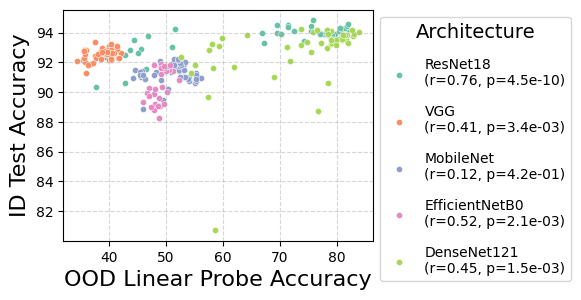

In [4]:
fig, axs = plt.subplots(1, 1, sharex=True, figsize=(4, 3))
palette = sns.color_palette("Set2", n_colors=len(arch_list))

for i, arch_name in enumerate(arch_list):
    df_arch = df[df['arch_name'] == arch_name]
    x = df_arch['acc_lp_ood']
    y = df_arch['acc_test']
    r, p = linregress(x, y)[2:4]  # r_value and p_value
    sns.scatterplot(data=df_arch, x=x, y=y, ax=axs, label=f'{arch_name}\n(r={r:.2f}, p={p:.1e})', s=s, color=palette[i])

axs.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, title='Architecture', labelspacing=1.2, title_fontsize=14)
axs.set_ylabel('ID Test Accuracy', fontsize=16)
axs.set_xlabel('OOD Linear Probe Accuracy', fontsize=16)
axs.grid(True, linestyle='--', alpha=0.5)

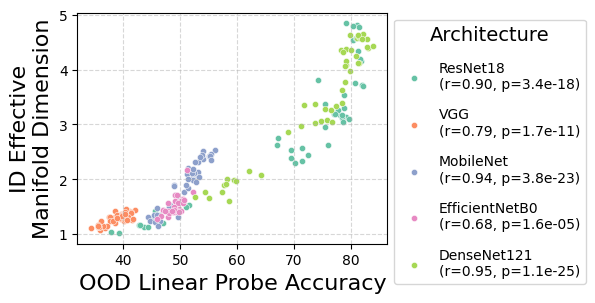

In [5]:
fig, axs = plt.subplots(1, 1, sharex=True, figsize=(4, 3))
palette = sns.color_palette("Set2", n_colors=len(arch_list))

for i, arch_name in enumerate(arch_list):
    df_arch = df[df['arch_name'] == arch_name]
    x = df_arch['acc_lp_ood']
    y = df_arch['dimension_id']
    r, p = linregress(x, y)[2:4]  # r_value and p_value
    sns.scatterplot(data=df_arch, x=x, y=y, ax=axs, label=f'{arch_name}\n(r={r:.2f}, p={p:.1e})', s=s, color=palette[i])

axs.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, title='Architecture', labelspacing=1.2, title_fontsize=14)
axs.set_ylabel('ID Effective\nManifold Dimension', fontsize=16)
axs.set_xlabel('OOD Linear Probe Accuracy', fontsize=16)
axs.grid(True, linestyle='--', alpha=0.5)

# Fig 4

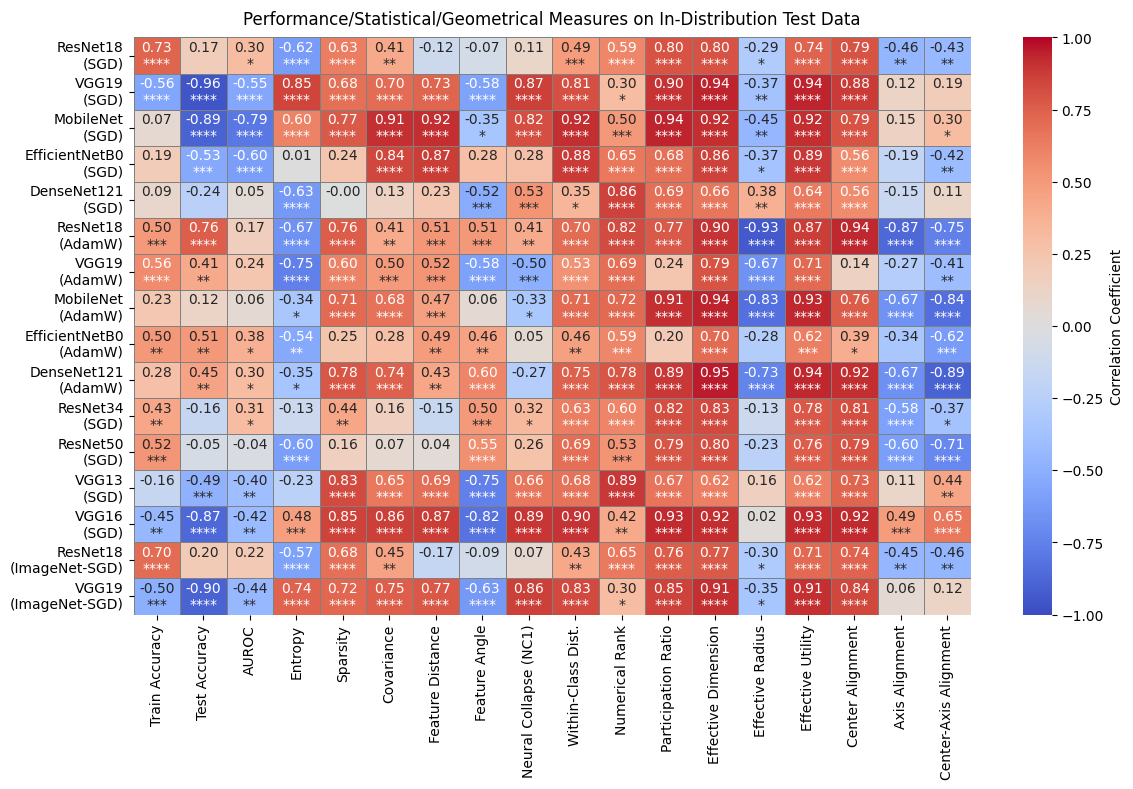

In [6]:
with open('data/df_fig4.pkl', 'rb') as f:
    df = pickle.load(f)

arch_name_list = ['ResNet18\n(SGD)', 'VGG19\n(SGD)', 'MobileNet\n(SGD)', 'EfficientNetB0\n(SGD)', 'DenseNet121\n(SGD)',
    'ResNet18\n(AdamW)', 'VGG19\n(AdamW)', 'MobileNet\n(AdamW)', 'EfficientNetB0\n(AdamW)', 'DenseNet121\n(AdamW)',
    'ResNet34\n(SGD)', 'ResNet50\n(SGD)', 'VGG13\n(SGD)', 'VGG16\n(SGD)',
    'ResNet18\n(ImageNet-SGD)', 'VGG19\n(ImageNet-SGD)']
key_list = ['acc_train', 'acc_test', 'auroc', 'entropy', 'sparsity_id', 'mean_covariance_id', 'mean_distance_id', 'mean_angle_id',
    'nc1_id', 'mean_distance_avg_id', 'numerical_rank_id',
    'participation_ratio_id', 'dimension_id', 'radius_id', 'utility_id',
    'center_alignment_id', 'axis_alignment_id', 'center_axis_alignment_id']

key_name_list = ['Train Accuracy', 'Test Accuracy', 'AUROC', 'Entropy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'Neural Collapse (NC1)', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

r_matrix, p_matrix, annot_matrix = get_r_p(df, arch_name_list)

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1
)

plt.title(f'Performance/Statistical/Geometrical Measures on In-Distribution Test Data', fontsize=12, y=1.01)
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.xticks(ticks=np.arange(len(key_list))+0.5, labels=key_name_list, rotation=90, ha='center', fontsize=10)
plt.tight_layout()

# Fig 6 (Training data geometry vs. OOD performance)

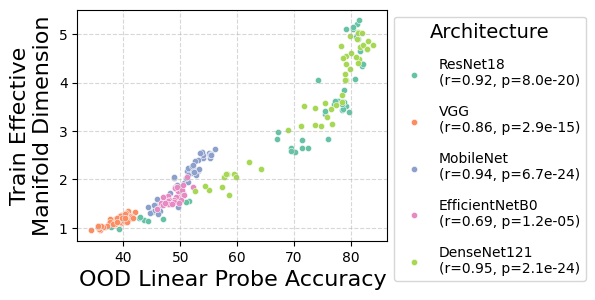

In [7]:
with open('data/df_fig3.pkl', 'rb') as f:
    df = pickle.load(f)

fig, axs = plt.subplots(1, 1, sharex=True, figsize=(4, 3))
palette = sns.color_palette("Set2", n_colors=len(arch_list))

for i, arch_name in enumerate(arch_list):
    df_arch = df[df['arch_name'] == arch_name]
    x = df_arch['acc_lp_ood']
    y = df_arch['dimension_train']
    r, p = linregress(x, y)[2:4]
    sns.scatterplot(data=df_arch, x=x, y=y, ax=axs, label=f'{arch_name}\n(r={r:.2f}, p={p:.1e})', s=s, color=palette[i])

axs.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, title='Architecture', labelspacing=1.2, title_fontsize=14)
axs.set_ylabel('Train Effective\nManifold Dimension', fontsize=16)
axs.set_xlabel('OOD Linear Probe Accuracy', fontsize=16)
axs.grid(True, linestyle='--', alpha=0.5)


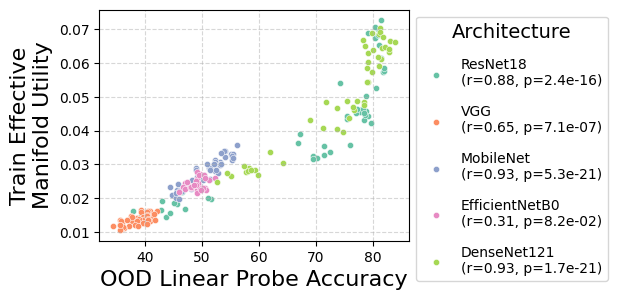

In [8]:
fig, axs = plt.subplots(1, 1, sharex=True, figsize=(4, 3))
palette = sns.color_palette("Set2", n_colors=len(arch_list))

for i, arch_name in enumerate(arch_list):
    df_arch = df[df['arch_name'] == arch_name]
    x = df_arch['acc_lp_ood']
    y = df_arch['utility_train']
    r, p = linregress(x, y)[2:4]
    sns.scatterplot(data=df_arch, x=x, y=y, ax=axs, label=f'{arch_name}\n(r={r:.2f}, p={p:.1e})', s=s, color=palette[i])

axs.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, title='Architecture', labelspacing=1.2, title_fontsize=14)
axs.set_ylabel('Train Effective\nManifold Utility', fontsize=16)
axs.set_xlabel('OOD Linear Probe Accuracy', fontsize=16)
axs.grid(True, linestyle='--', alpha=0.5)


# Fig 7 & 8 (Varying architecture; SGD)

In [9]:
with open('data/df_fig7+8.pkl', 'rb') as f:
    df_5dnn_sgd_train = pickle.load(f)
    df_5dnn_sgd_test = pickle.load(f)

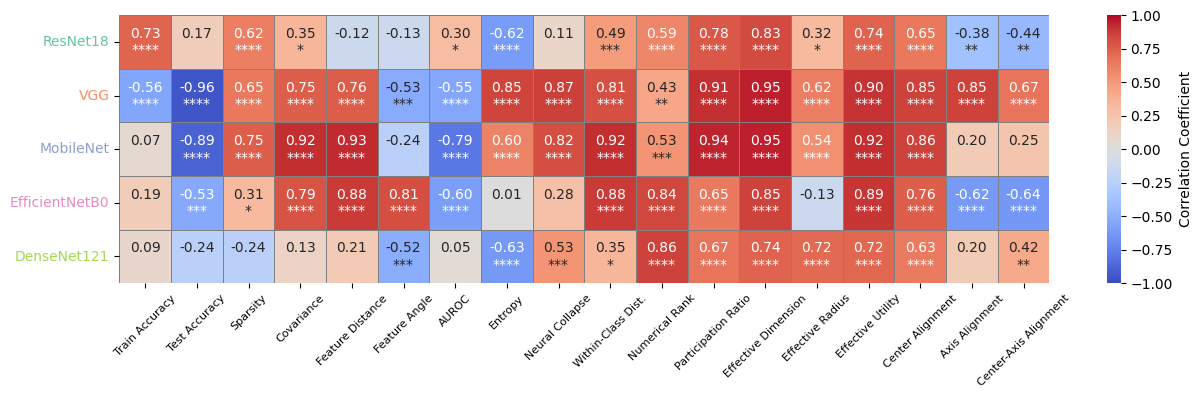

In [10]:
key_list = ['acc_train', 'acc_test', 'sparsity_train', 'mean_covariance_train', 'mean_distance_train', 'mean_angle_train',
    'auroc', 'entropy', 'nc1_id', 'mean_distance_avg_id', 'numerical_rank_train',
    'participation_ratio_train', 'dimension_train', 'radius_train', 'utility_train',
    'center_alignment_train', 'axis_alignment_train', 'center_axis_alignment_train']
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'AUROC', 'Entropy', 'Neural Collapse', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

arch_name_list = ['ResNet18', 'VGG', 'MobileNet', 'EfficientNetB0', 'DenseNet121']

fig = plt.figure(figsize=(15, 12))

# Outer GridSpec: 2 rows (heatmap, scatterplots)
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.3)  # gap between A and B

# ===== Top: Heatmap (A) =====
ax0 = fig.add_subplot(outer_gs[0, 0])

r_matrix, p_matrix, annot_matrix = get_r_p(df_5dnn_sgd_train, arch_name_list)
sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1,
    ax=ax0
)

ax0.set_ylabel('', fontsize=12)
ax0.set_xlabel('')
ax0.set_xticks(np.arange(len(key_list)) + 0.5)
ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

set2_colors = plt.get_cmap('Set2').colors
for label, color in zip(ax0.get_yticklabels(), set2_colors):
    label.set_color(color)

# ===== Bottom: Scatter plots (B) =====


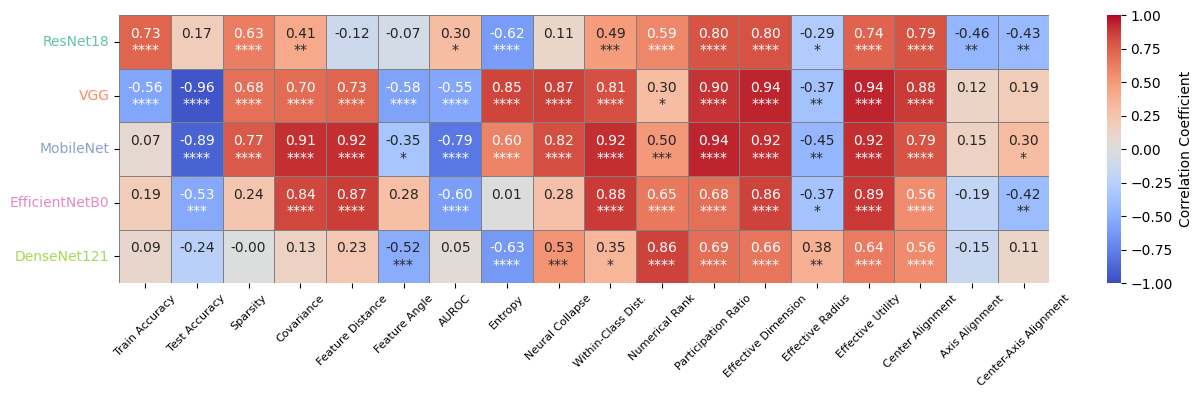

In [11]:
key_list = ['acc_train', 'acc_test', 'sparsity_id', 'mean_covariance_id', 'mean_distance_id', 'mean_angle_id',
    'auroc', 'entropy', 'nc1_id', 'mean_distance_avg_id', 'numerical_rank_id',
    'participation_ratio_id', 'dimension_id', 'radius_id', 'utility_id',
    'center_alignment_id', 'axis_alignment_id', 'center_axis_alignment_id']
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'AUROC', 'Entropy', 'Neural Collapse', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

arch_name_list = ['ResNet18', 'VGG', 'MobileNet', 'EfficientNetB0', 'DenseNet121']

fig = plt.figure(figsize=(15, 12))

# Outer GridSpec: 2 rows (heatmap, scatterplots)
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.3)  # gap between A and B

# ===== Top: Heatmap (A) =====
ax0 = fig.add_subplot(outer_gs[0, 0])

r_matrix, p_matrix, annot_matrix = get_r_p(df_5dnn_sgd_test, arch_name_list)
sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1,
    ax=ax0
)

ax0.set_ylabel('', fontsize=12)
ax0.set_xlabel('')
ax0.set_xticks(np.arange(len(key_list)) + 0.5)
ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

set2_colors = plt.get_cmap('Set2').colors
for label, color in zip(ax0.get_yticklabels(), set2_colors):
    label.set_color(color)

# ===== Bottom: Scatter plots (B) =====


# Fig 9 & 10 (Varying architecture; AdamW)

In [12]:
with open('data/df_fig9+10.pkl', 'rb') as f:
    df_5dnn_adamw_train = pickle.load(f)
    df_5dnn_adamw_test = pickle.load(f)

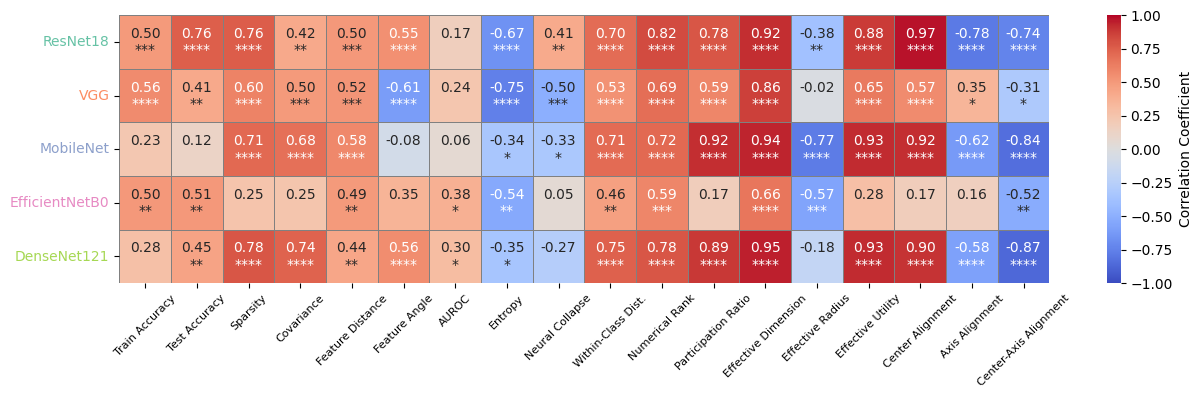

In [13]:
key_list = ['acc_train', 'acc_test', 'sparsity_train', 'mean_covariance_train', 'mean_distance_train', 'mean_angle_train',
    'auroc', 'entropy', 'nc1_id', 'mean_distance_avg_id', 'numerical_rank_train',
    'participation_ratio_train', 'dimension_train', 'radius_train', 'utility_train',
    'center_alignment_train', 'axis_alignment_train', 'center_axis_alignment_train']
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'AUROC', 'Entropy', 'Neural Collapse', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

arch_name_list = ['ResNet18', 'VGG', 'MobileNet', 'EfficientNetB0', 'DenseNet121']

fig = plt.figure(figsize=(15, 12))

# Outer GridSpec: 2 rows (heatmap, scatterplots)
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.3)  # gap between A and B

# ===== Top: Heatmap (A) =====
ax0 = fig.add_subplot(outer_gs[0, 0])

r_matrix, p_matrix, annot_matrix = get_r_p(df_5dnn_adamw_train, arch_name_list)
sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1,
    ax=ax0
)

ax0.set_ylabel('', fontsize=12)
ax0.set_xlabel('')
ax0.set_xticks(np.arange(len(key_list)) + 0.5)
ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

set2_colors = plt.get_cmap('Set2').colors
for label, color in zip(ax0.get_yticklabels(), set2_colors):
    label.set_color(color)

# ===== Bottom: Scatter plots (B) =====


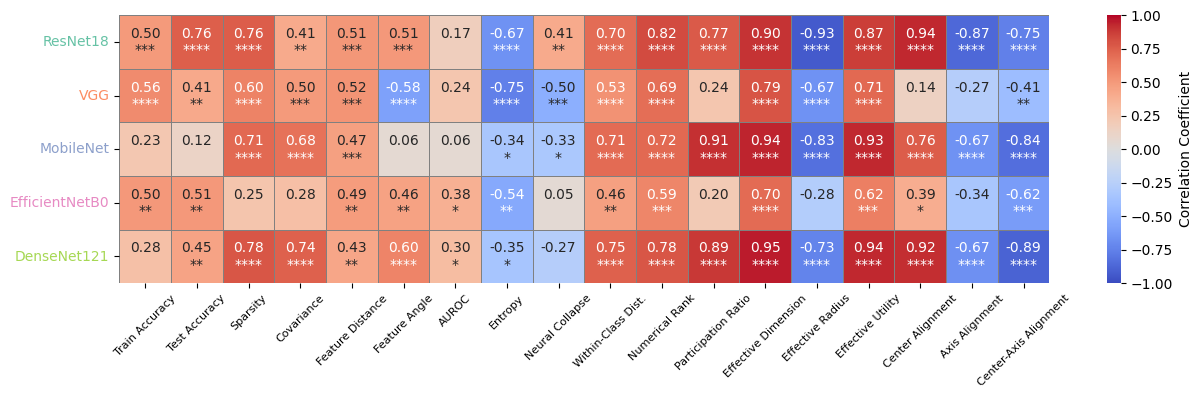

In [14]:
key_list = ['acc_train', 'acc_test', 'sparsity_id', 'mean_covariance_id', 'mean_distance_id', 'mean_angle_id',
    'auroc', 'entropy', 'nc1_id', 'mean_distance_avg_id', 'numerical_rank_id',
    'participation_ratio_id', 'dimension_id', 'radius_id', 'utility_id',
    'center_alignment_id', 'axis_alignment_id', 'center_axis_alignment_id']
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'AUROC', 'Entropy', 'Neural Collapse', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

arch_name_list = ['ResNet18', 'VGG', 'MobileNet', 'EfficientNetB0', 'DenseNet121']

fig = plt.figure(figsize=(15,12))

# Outer GridSpec: 2 rows (heatmap, scatterplots)
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.3)  # gap between A and B

# ===== Top: Heatmap (A) =====
ax0 = fig.add_subplot(outer_gs[0, 0])

r_matrix, p_matrix, annot_matrix = get_r_p(df_5dnn_adamw_test, arch_name_list)
sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1,
    ax=ax0
)

ax0.set_ylabel('', fontsize=12)
ax0.set_xlabel('')
ax0.set_xticks(np.arange(len(key_list)) + 0.5)
ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

set2_colors = plt.get_cmap('Set2').colors
for label, color in zip(ax0.get_yticklabels(), set2_colors):
    label.set_color(color)

# ===== Bottom: Scatter plots (B) =====


# Fig 11 & 12 (Varying depth; SGD)

In [15]:
with open('data/df_fig11+12.pkl', 'rb') as f:
    df_depth_sgd_train = pickle.load(f)
    df_depth_sgd_test = pickle.load(f)

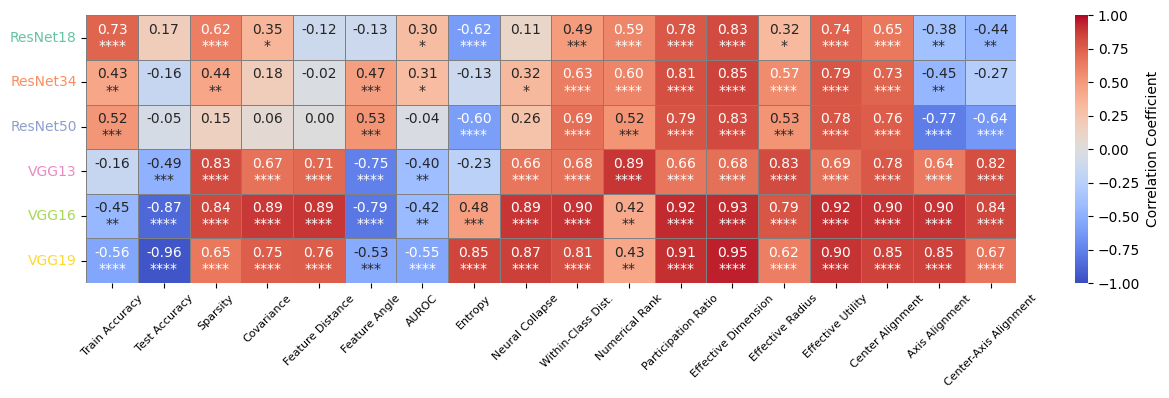

In [16]:
key_list = ['acc_train', 'acc_test', 'sparsity_train', 'mean_covariance_train', 'mean_distance_train', 'mean_angle_train',
    'auroc', 'entropy', 'nc1_id', 'mean_distance_avg_id', 'numerical_rank_train',
    'participation_ratio_train', 'dimension_train', 'radius_train', 'utility_train',
    'center_alignment_train', 'axis_alignment_train', 'center_axis_alignment_train']
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'AUROC', 'Entropy', 'Neural Collapse', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

arch_name_list = ['ResNet18', 'ResNet34', 'ResNet50', 'VGG13', 'VGG16','VGG']
arch_name_real_list = ['ResNet18', 'ResNet34', 'ResNet50', 'VGG13', 'VGG16','VGG19']

fig = plt.figure(figsize=(15, 12))

# Outer GridSpec: 2 rows (heatmap, scatterplots)
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.3)  # gap between A and B

# ===== Top: Heatmap (A) =====
ax0 = fig.add_subplot(outer_gs[0, 0])

r_matrix, p_matrix, annot_matrix = get_r_p(df_depth_sgd_train, arch_name_list)
sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1,
    ax=ax0
)

ax0.set_ylabel('', fontsize=12)
ax0.set_xlabel('')
ax0.set_xticks(np.arange(len(key_list)) + 0.5)
ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
ax0.set_yticklabels(arch_name_real_list, rotation=0)

set2_colors = plt.get_cmap('Set2').colors
for label, color in zip(ax0.get_yticklabels(), set2_colors):
    label.set_color(color)

# ===== Bottom: Scatter plots (B) =====


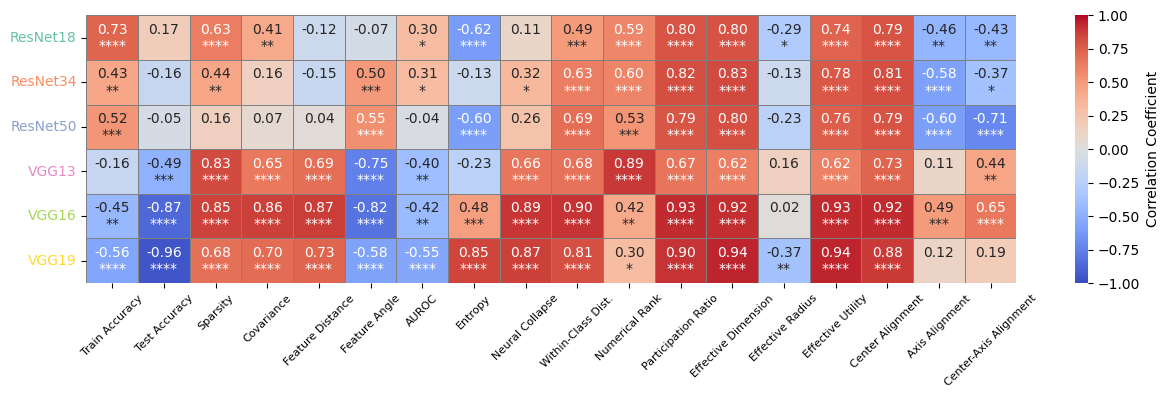

In [17]:
key_list = ['acc_train', 'acc_test', 'sparsity_id', 'mean_covariance_id', 'mean_distance_id', 'mean_angle_id',
    'auroc', 'entropy', 'nc1_id', 'mean_distance_avg_id', 'numerical_rank_id',
    'participation_ratio_id', 'dimension_id', 'radius_id', 'utility_id',
    'center_alignment_id', 'axis_alignment_id', 'center_axis_alignment_id']
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'AUROC', 'Entropy', 'Neural Collapse', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

arch_name_list = ['ResNet18', 'ResNet34', 'ResNet50', 'VGG13', 'VGG16','VGG']
arch_name_real_list = ['ResNet18', 'ResNet34', 'ResNet50', 'VGG13', 'VGG16','VGG19']

fig = plt.figure(figsize=(15, 12))

# Outer GridSpec: 2 rows (heatmap, scatterplots)
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.3)  # gap between A and B

# ===== Top: Heatmap (A) =====
ax0 = fig.add_subplot(outer_gs[0, 0])

r_matrix, p_matrix, annot_matrix = get_r_p(df_depth_sgd_test, arch_name_list)
sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1,
    ax=ax0
)

ax0.set_ylabel('', fontsize=12)
ax0.set_xlabel('')
ax0.set_xticks(np.arange(len(key_list)) + 0.5)
ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
ax0.set_yticklabels(arch_name_real_list, rotation=0)

set2_colors = plt.get_cmap('Set2').colors
for label, color in zip(ax0.get_yticklabels(), set2_colors):
    label.set_color(color)

# ===== Bottom: Scatter plots (B) =====


# Fig 13 & 14 (ImageNet as OOD data; SGD)

In [18]:
with open('data/df_fig13+14.pkl', 'rb') as f:
    df_imagenet_sgd_train = pickle.load(f)
    df_imagenet_sgd_test = pickle.load(f)

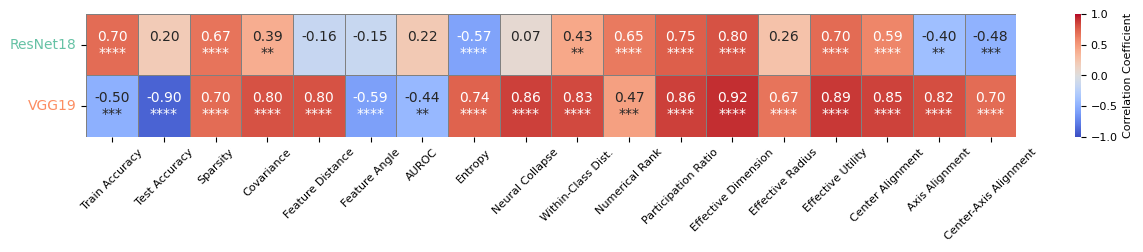

In [19]:
key_list = ['acc_train', 'acc_test', 'sparsity_train', 'mean_covariance_train', 'mean_distance_train', 'mean_angle_train',
    'auroc', 'entropy', 'nc1_id', 'mean_distance_avg_id', 'numerical_rank_train',
    'participation_ratio_train', 'dimension_train', 'radius_train', 'utility_train',
    'center_alignment_train', 'axis_alignment_train', 'center_axis_alignment_train']
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'AUROC', 'Entropy', 'Neural Collapse', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

arch_name_list = ['ResNet18', 'VGG']
arch_name_real_list = ['ResNet18', 'VGG19']

fig = plt.figure(figsize=(15, 10))

# Outer GridSpec: 2 rows (heatmap, scatterplots)
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[0.5, 2], hspace=0.5)  # gap between A and B

# ===== Top: Heatmap (A) =====
ax0 = fig.add_subplot(outer_gs[0, 0])

r_matrix, p_matrix, annot_matrix = get_r_p(df_imagenet_sgd_train, arch_name_list)
sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1,
    ax=ax0
)

cbar_ax = ax0.figure.axes[-1]
cbar_ax.tick_params(labelsize=8) # Adjust tick label font size
cbar_ax.yaxis.label.set_size(8) # Adjust colorbar label font size


ax0.set_ylabel('', fontsize=12)
ax0.set_xlabel('')
ax0.set_xticks(np.arange(len(key_list)) + 0.5)
ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
ax0.set_yticklabels(arch_name_real_list, rotation=0)

set2_colors = plt.get_cmap('Set2').colors
for label, color in zip(ax0.get_yticklabels(), set2_colors):
    label.set_color(color)

# ===== Bottom: Scatter plots (B) =====


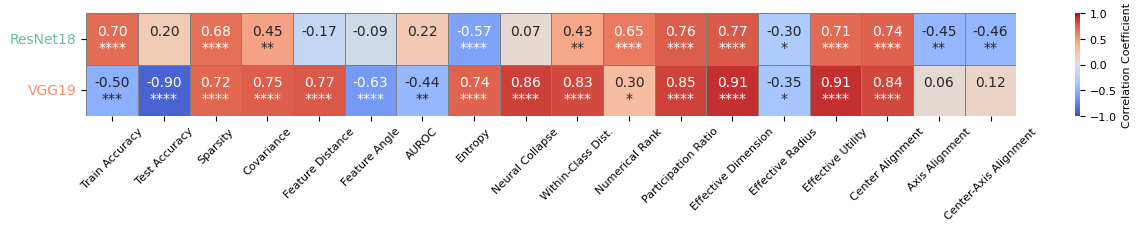

In [20]:
key_list = ['acc_train', 'acc_test', 'sparsity_id', 'mean_covariance_id', 'mean_distance_id', 'mean_angle_id',
    'auroc', 'entropy', 'nc1_id', 'mean_distance_avg_id', 'numerical_rank_id',
    'participation_ratio_id', 'dimension_id', 'radius_id', 'utility_id',
    'center_alignment_id', 'axis_alignment_id', 'center_axis_alignment_id']
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'AUROC', 'Entropy', 'Neural Collapse', 'Within-Class Dist.', 'Numerical Rank',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility',
    'Center Alignment', 'Axis Alignment', 'Center-Axis Alignment']

arch_name_list = ['ResNet18','VGG']
arch_name_real_list = ['ResNet18','VGG19']

fig = plt.figure(figsize=(15, 10))

# Outer GridSpec: 2 rows (heatmap, scatterplots)
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[0.4, 2], hspace=0.5)  # gap between A and B

# ===== Top: Heatmap (A) =====
ax0 = fig.add_subplot(outer_gs[0, 0])

r_matrix, p_matrix, annot_matrix = get_r_p(df_imagenet_sgd_test, arch_name_list)
sns.heatmap(
    r_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray',
    vmin=-1,
    vmax=1,
    ax=ax0
)

cbar_ax = ax0.figure.axes[-1]
cbar_ax.tick_params(labelsize=8) # Adjust tick label font size
cbar_ax.yaxis.label.set_size(8) # Adjust colorbar label font size


ax0.set_ylabel('', fontsize=12)
ax0.set_xlabel('')
ax0.set_xticks(np.arange(len(key_list)) + 0.5)
ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
ax0.set_yticklabels(arch_name_real_list, rotation=0)

set2_colors = plt.get_cmap('Set2').colors
for label, color in zip(ax0.get_yticklabels(), set2_colors):
    label.set_color(color)

# ===== Bottom: Scatter plots (B) =====


# Fig 15-20 (Corrupted images as OOD data; SGD)

In [21]:
with open('data/df_fig15-20.pkl', 'rb') as f:
    df_dict = pickle.load(f)

In [22]:
key_list = ['acc_train', 'acc_test',
        'sparsity_id', 'mean_covariance_id', 'mean_distance_id', 'mean_angle_id',
        'participation_ratio_id', 'dimension_id', 'radius_id', 'utility_id',
        ]
key_name_list = ['Train Accuracy', 'Test Accuracy', 'Sparsity', 'Covariance', 'Feature Distance', 'Feature Angle',
    'Participation Ratio', 'Effective Dimension', 'Effective Radius', 'Effective Utility']

arch_name_list = ['ResNet18', 'VGG', 'MobileNet', 'EfficientNetB0', 'DenseNet121']

def my_plot(df_result_combined, suptitle=None, filename=None):
    # arch_name_list = ['VGG']

    ret_list = []
    for arch_name in arch_name_list:
        df_arch = df_result_combined[df_result_combined['arch_name'] == arch_name]
        for key in key_list:
            x = df_arch['acc_test_c']
            y = df_arch[key]
            r, p = linregress(x, y)[2:4]  # r_value and p_value

            # save r and p to df_list
            ret = {'r': r, 'p': p, 'arch_name': arch_name, 'property': key}
            ret_list.append(ret)

    df = pd.DataFrame(ret_list)
    df_5dnn_sgd_train =  pd.DataFrame(ret_list)

    fig = plt.figure(figsize=(12, 8))

    # Outer GridSpec: 2 rows (heatmap, scatterplots)
    outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1.1, 2], hspace=0.6)  # gap between A and B

    # ===== Top: Heatmap (A) =====
    ax0 = fig.add_subplot(outer_gs[0, 0])

    r_matrix, p_matrix, annot_matrix = get_r_p(df, arch_name_list)
    sns.heatmap(
        r_matrix,
        annot=annot_matrix,
        fmt='',
        cmap='coolwarm',
        cbar_kws={'label': 'Correlation Coefficient'},
        linewidths=0.5,
        linecolor='gray',
        vmin=-1,
        vmax=1,
        ax=ax0
    )

    ax0.set_ylabel('', fontsize=12)
    ax0.set_xlabel('')
    ax0.set_xticks(np.arange(len(key_list)) + 0.5)
    ax0.set_xticklabels(key_name_list, rotation=45, ha='center', fontsize=8)
    ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

    set2_colors = plt.get_cmap('Set2').colors
    for label, color in zip(ax0.get_yticklabels(), set2_colors):
        label.set_color(color)

    # ===== Bottom: Scatter plots (B) =====


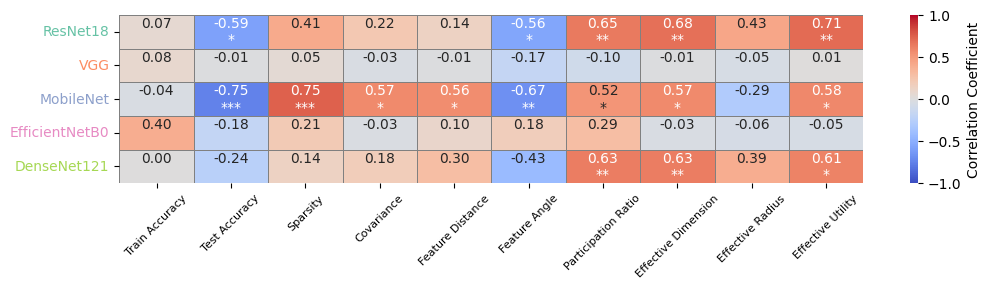

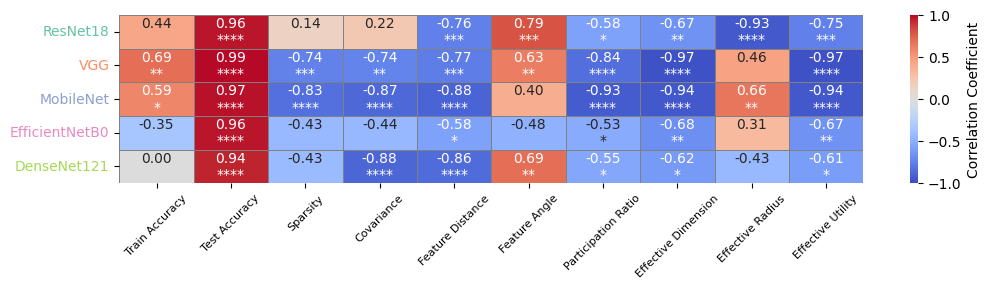

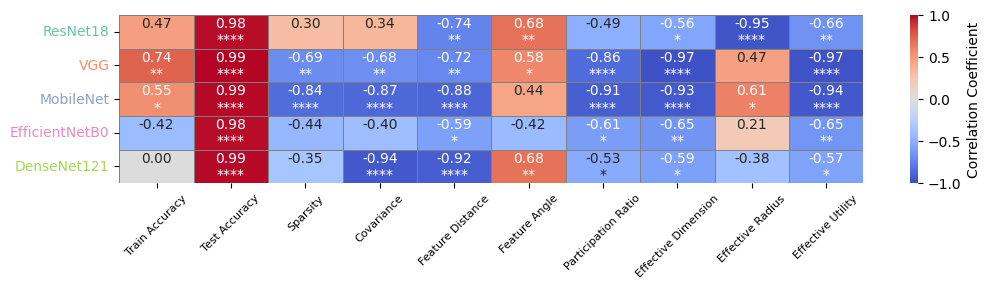

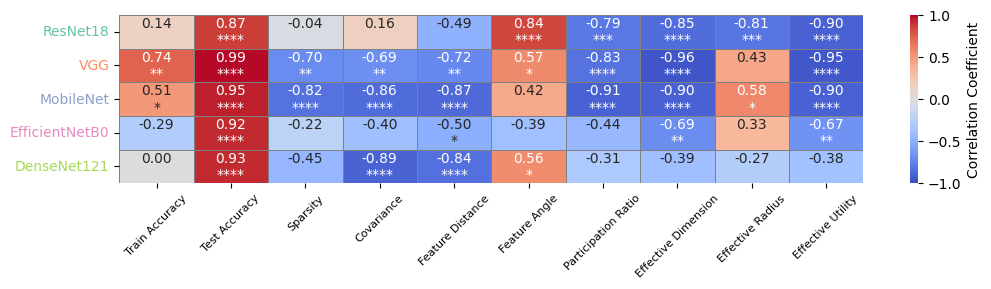

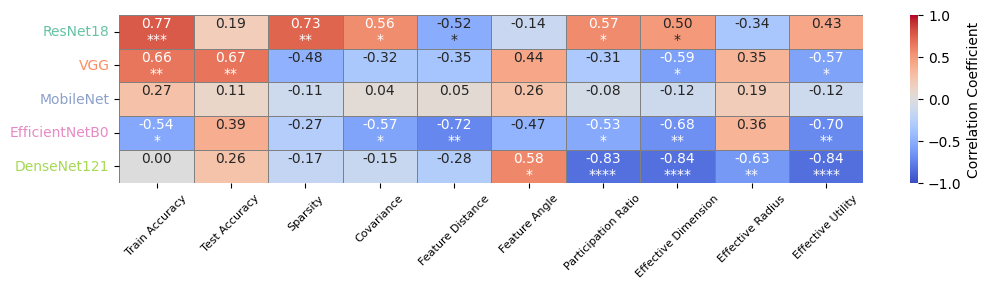

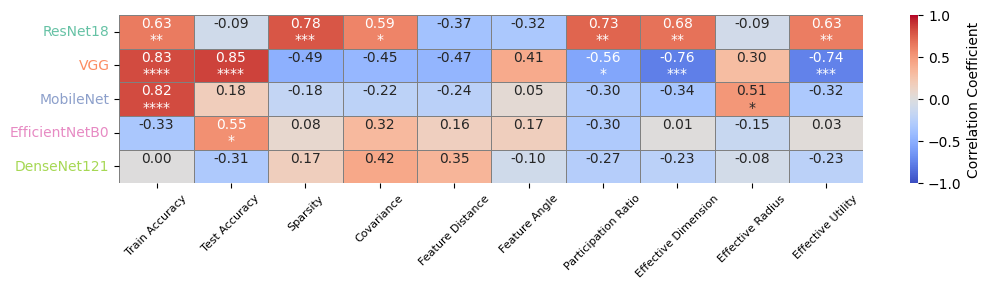

In [23]:
corruption_list_short = ['gaussian_noise', 'fog', 'brightness', 'contrast', 'pixelate','jpeg_compression']
for corruption in corruption_list_short:
    my_plot(df_dict[corruption], suptitle=f'Corruption: {corruption}')